# Round 3 Voucher 策略验证
按 `round3_validation_spec.md` 实施。数据：`data/bt/prices_round_3_day_{0,1,2}.csv` 与对应 `trades_round_3_day_*.csv`。

TTE 约定（来自 PDF）：historical day 0 → TTE=8d at start，day 1 → 7d，day 2 → 6d。每天 timestamp 从 0 → 999900（步长 100），单日跨度 1 天，年化 T = TTE_days/365。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from statsmodels.tsa.stattools import adfuller, acf
import warnings; warnings.filterwarnings('ignore')

DATA = 'data/bt'
STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500]
TICKS_PER_DAY = 10000  # timestamp step 100, 0..999900
DAYS_TTE_START = {0: 8, 1: 7, 2: 6}  # 历史 day -> 当天开始时剩余天数
POS_LIMIT_VOUCHER = 300
POS_LIMIT_VFE = 200

## Section 1 — 基础设施：BS 工具 + 数据加载

In [2]:
def _d1(S, K, T, sigma):
    return (np.log(S/K) + 0.5*sigma*sigma*T) / (sigma*np.sqrt(T))

def bs_price(S, K, T, sigma, r=0.0):
    if T <= 0 or sigma <= 0: return max(S-K, 0.0)
    d1 = _d1(S,K,T,sigma); d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def bs_delta(S, K, T, sigma, r=0.0):
    if T <= 0 or sigma <= 0: return 1.0 if S>K else 0.0
    return norm.cdf(_d1(S,K,T,sigma))

def bs_vega(S, K, T, sigma, r=0.0):
    if T <= 0 or sigma <= 0: return 0.0
    return S*norm.pdf(_d1(S,K,T,sigma))*np.sqrt(T)

def bs_iv_from_price(price, S, K, T, r=0.0):
    intrinsic = max(S-K, 0.0)
    if not np.isfinite(price) or price <= intrinsic + 1e-9 or price >= S - 1e-9 or T <= 0:
        return np.nan
    f = lambda s: bs_price(S,K,T,s,r) - price
    try:
        return brentq(f, 1e-4, 5.0, xtol=1e-6, maxiter=100)
    except Exception:
        return np.nan

In [3]:
def load_day(day):
    p = pd.read_csv(f'{DATA}/prices_round_3_day_{day}.csv', sep=';')
    t = pd.read_csv(f'{DATA}/trades_round_3_day_{day}.csv', sep=';')
    p['day'] = day; t['day'] = day
    return p, t

prices_list, trades_list = [], []
for d in (0,1,2):
    p, t = load_day(d); prices_list.append(p); trades_list.append(t)
prices = pd.concat(prices_list, ignore_index=True)
trades = pd.concat(trades_list, ignore_index=True)

prices['global_ts'] = prices['day']*1_000_000 + prices['timestamp']
trades['global_ts'] = trades['day']*1_000_000 + trades['timestamp']

prices['T'] = (prices['day'].map(DAYS_TTE_START) - prices['timestamp']/1_000_000) / 365.0

print('prices:', prices.shape, 'trades:', trades.shape)
print('products:', sorted(prices['product'].unique()))


prices: (360000, 19) trades: (4048, 9)
products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


In [4]:
# 转宽表：每个 product 的 mid/bid/ask/sizes
def pivot_field(df, field):
    return df.pivot(index='global_ts', columns='product', values=field).sort_index()

mid = pivot_field(prices, 'mid_price')
bid1 = pivot_field(prices, 'bid_price_1')
ask1 = pivot_field(prices, 'ask_price_1')
bidv1 = pivot_field(prices, 'bid_volume_1')
askv1 = pivot_field(prices, 'ask_volume_1')
T_ser = prices.groupby('global_ts')['T'].first()
day_ser = prices.groupby('global_ts')['day'].first()

S = mid['VELVETFRUIT_EXTRACT']
print('rows:', len(mid), '| S range:', S.min(), S.max())
print('NaN in mids:'); print(mid[[f'VEV_{k}' for k in STRIKES]].isna().sum())

rows: 30000 | S range: 5198.0 5300.0
NaN in mids:
product
VEV_4000    0
VEV_4500    0
VEV_5000    0
VEV_5100    0
VEV_5200    0
VEV_5300    0
VEV_5400    0
VEV_5500    0
dtype: int64


In [5]:
# 反推 mid IV（vector via apply per row 太慢；用循环但只对 8 个 strike）
iv = pd.DataFrame(index=mid.index, columns=[f'iv_{k}' for k in STRIKES], dtype=float)
for K in STRIKES:
    col = f'VEV_{K}'
    prices_v = mid[col].values; S_v = S.values; T_v = T_ser.values
    out = np.full(len(mid), np.nan)
    for i in range(len(mid)):
        out[i] = bs_iv_from_price(prices_v[i], S_v[i], K, T_v[i])
    iv[f'iv_{K}'] = out
print('IV NaN counts:'); print(iv.isna().sum())
iv.describe()

IV NaN counts:
iv_4000    27014
iv_4500    21177
iv_5000       24
iv_5100        0
iv_5200        0
iv_5300        0
iv_5400        0
iv_5500        0
dtype: int64


,iv_4000,iv_4500,iv_5000,iv_5100,iv_5200,iv_5300,iv_5400,iv_5500
count,2986.000000,8823.000000,29976.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.825960,0.467143,0.241988,0.239656,0.242338,0.244984,0.229623,0.249106
std,0.098225,0.047140,0.007138,0.005082,0.003442,0.004422,0.003698,0.004186
min,0.672978,0.398106,0.182072,0.217296,0.227933,0.233282,0.220078,0.236805
25%,0.747348,0.432229,0.238585,0.236033,0.240184,0.241195,0.227132,0.246068
50%,0.816624,0.457181,0.241889,0.239276,0.242657,0.245885,0.229540,0.249278
75%,0.881089,0.491570,0.245270,0.243484,0.244688,0.248565,0.231578,0.252044
max,1.181856,0.701817,0.294426,0.258991,0.254475,0.255949,0.242818,0.261497


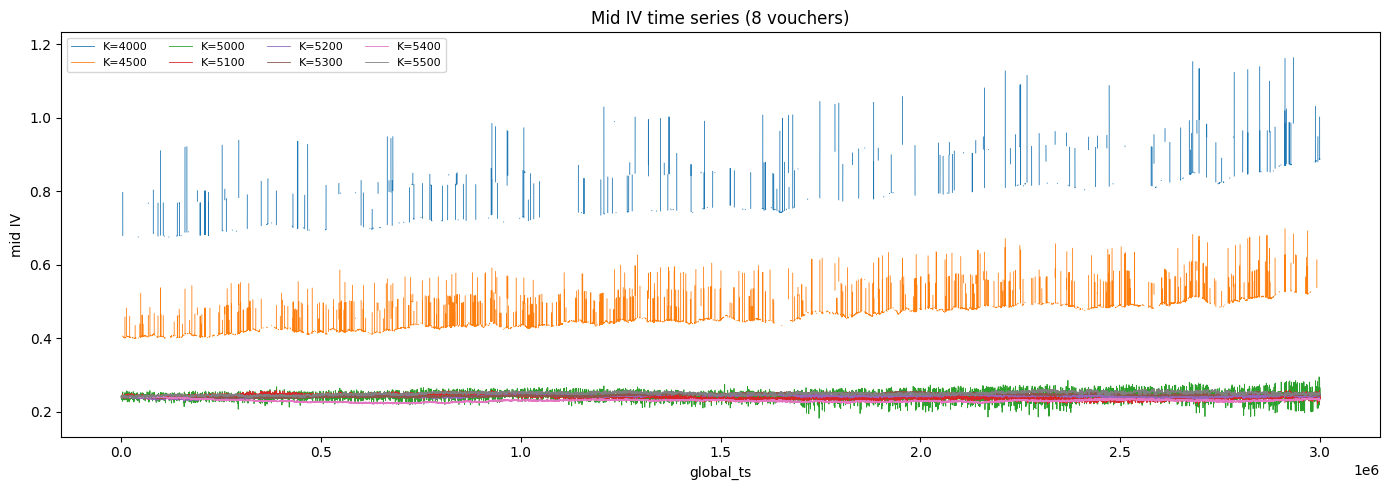

In [6]:
# Sanity check: 8 个 voucher mid-IV 时序
fig, ax = plt.subplots(figsize=(14,5))
for K in STRIKES:
    ax.plot(iv.index.values, iv[f'iv_{K}'].values, label=f'K={K}', lw=0.6)
ax.set_xlabel('global_ts'); ax.set_ylabel('mid IV'); ax.legend(ncol=4, fontsize=8)
ax.set_title('Mid IV time series (8 vouchers)')
plt.tight_layout(); plt.show()

**Section 1 总结**：3 天数据连续，timestamp 步长 100，每天 10000 ticks，共 30000 ticks。8 个 voucher mid-IV 全部有数据；4000/4500 深 ITM 价格几乎等于 intrinsic，IV 反推可能边界化（看上面 NaN 数）。

## Section 2 — VEV_4000 / 4500 的 delta 工具属性
### 2.1 实测 delta 回归 + 2.2 残差结构

In [7]:
def diff_no_cross(series, day_s):
    """一阶差分，跨 day 边界丢弃"""
    d = series.diff()
    cross = day_s.diff() != 0
    d[cross] = np.nan
    return d

dS = diff_no_cross(S, day_ser)
results_delta = []
for K in STRIKES:
    dV = diff_no_cross(mid[f'VEV_{K}'], day_ser)
    df = pd.concat([dS, dV, iv[f'iv_{K}']], axis=1).dropna()
    df.columns = ['dS','dV','iv']
    if len(df) < 100:
        results_delta.append({'K':K,'beta':np.nan}); continue
    x = df['dS'].values; y = df['dV'].values
    A = np.c_[np.ones_like(x), x]
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    alpha, beta = coef
    resid = y - A@coef
    ss_res = (resid**2).sum(); ss_tot = ((y - y.mean())**2).sum()
    r2 = 1 - ss_res/ss_tot
    # BS delta avg using each-tick IV
    sub = pd.concat([S, T_ser, iv[f'iv_{K}']], axis=1).dropna()
    sub.columns = ['S','T','iv']
    bs_d = np.array([bs_delta(s, K, t, v) for s,t,v in zip(sub['S'],sub['T'],sub['iv'])])
    bs_delta_avg = np.nanmean(bs_d)
    # residual ACF
    resid_s = pd.Series(resid)
    ac1 = resid_s.autocorr(lag=1) if len(resid_s)>2 else np.nan
    results_delta.append({
        'K':K,'n':len(df),'beta':beta,'alpha':alpha,'R2':r2,
        'resid_std':resid.std(),'BS_delta_avg':bs_delta_avg,'resid_acf1':ac1,
        '_resid':resid_s,'_bs_d_series':bs_d
    })
tab2 = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in results_delta])
tab2.round(4)

,K,n,beta,alpha,R2,resid_std,BS_delta_avg,resid_acf1
0,4000,2986,0.8100,1.1911,0.3163,1.5296,0.9938,-0.0379
1,4500,8823,0.7160,0.6075,0.4271,0.9612,0.9936,-0.1208
2,5000,29973,0.6530,0.0019,0.5695,0.6422,0.9359,-0.4088
3,5100,29997,0.5773,0.0001,0.5857,0.5492,0.8222,-0.4093
4,5200,29997,0.4367,-0.0001,0.5147,0.4796,0.6233,-0.4265
5,5300,29997,0.2727,-0.0003,0.3864,0.3887,0.3926,-0.4382
6,5400,29997,0.1289,-0.0003,0.2917,0.2272,0.1832,-0.4187
7,5500,29997,0.0549,-0.0001,0.1213,0.1671,0.0835,-0.3056


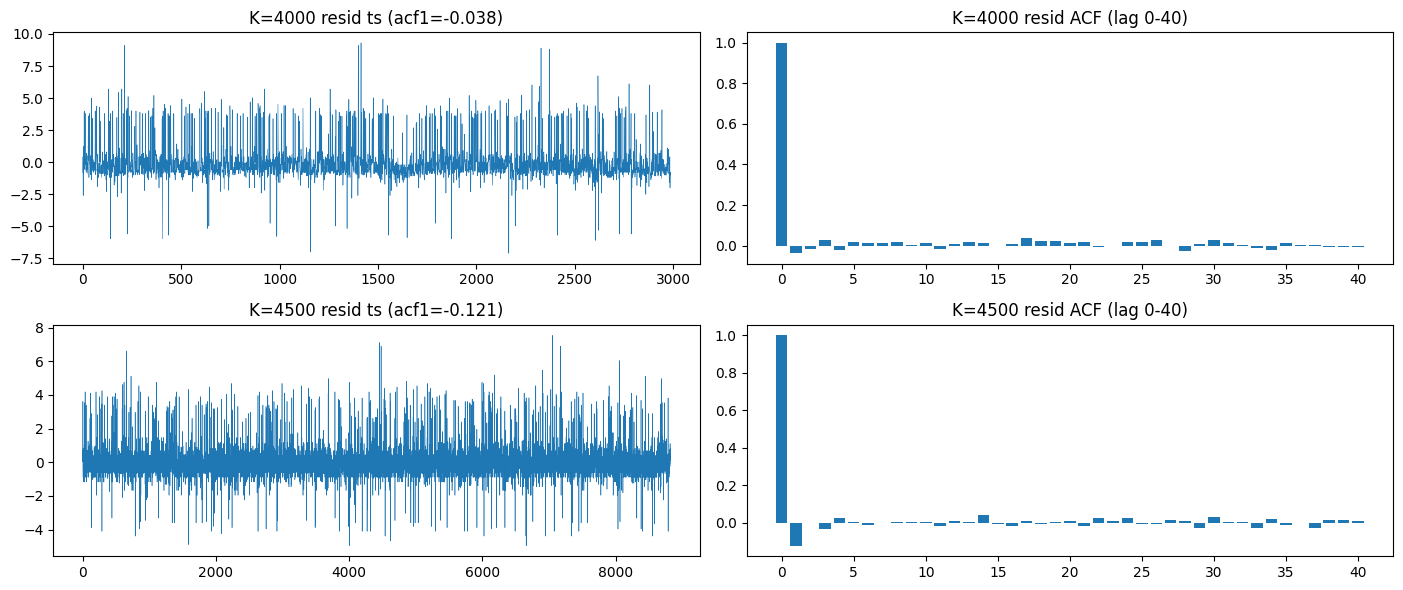

In [8]:
# 残差 ACF 与时序图（仅 4000、4500）
fig, axes = plt.subplots(2,2,figsize=(14,6))
for ax_row, K in zip(axes, [4000,4500]):
    r = next(x for x in results_delta if x['K']==K)
    resid = r['_resid'].values
    ax_row[0].plot(resid, lw=0.4); ax_row[0].set_title(f'K={K} resid ts (acf1={r["resid_acf1"]:.3f})')
    ac = acf(resid[~np.isnan(resid)][:5000], nlags=40, fft=True)
    ax_row[1].bar(range(len(ac)), ac); ax_row[1].set_title(f'K={K} resid ACF (lag 0-40)')
plt.tight_layout(); plt.show()

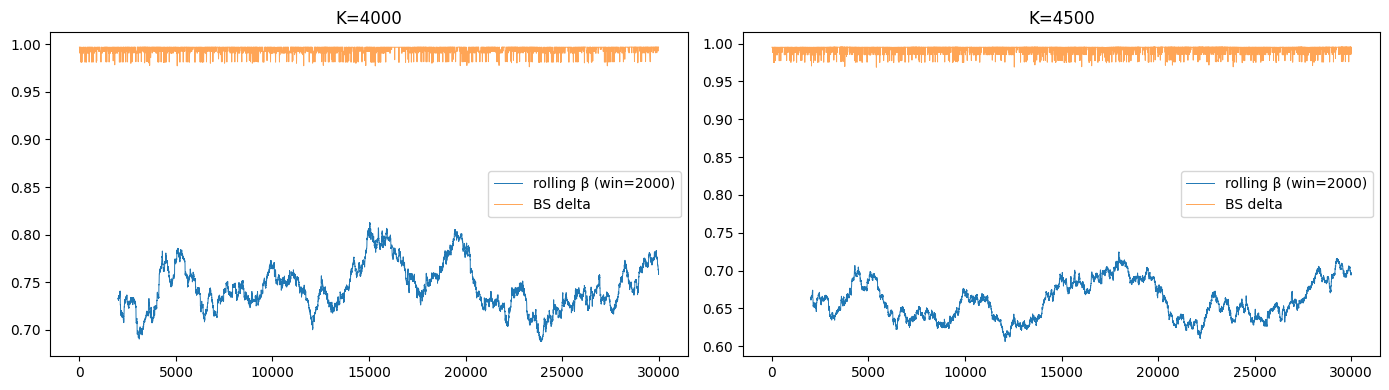

In [9]:
# 实测 β（rolling）vs BS delta（per-tick）—— 仅 4000/4500
fig, axes = plt.subplots(1,2,figsize=(14,4))
win = 2000
for ax, K in zip(axes, [4000,4500]):
    dV = diff_no_cross(mid[f'VEV_{K}'], day_ser)
    df = pd.concat([dS, dV], axis=1).dropna(); df.columns=['dS','dV']
    cov = df['dS'].rolling(win).cov(df['dV'])
    var = df['dS'].rolling(win).var()
    rb = cov/var
    sub = pd.concat([S, T_ser, iv[f'iv_{K}']], axis=1).dropna(); sub.columns=['S','T','iv']
    bsd = pd.Series([bs_delta(s,K,t,v) for s,t,v in zip(sub['S'],sub['T'],sub['iv'])], index=sub.index)
    ax.plot(rb.values, label=f'rolling β (win={win})', lw=0.7)
    ax.plot(np.linspace(0,len(rb)-1,len(bsd)), bsd.values, label='BS delta', lw=0.7, alpha=0.7)
    ax.set_title(f'K={K}'); ax.legend()
plt.tight_layout(); plt.show()

### 2.3 被动成交可达性（用 trade tape）

判定方法：把 trades 与 orderbook 对齐——若 trade price == 当 tick best_bid → "市价卖单"成交（说明在 best_bid 上挂买单的人成交了）；若 trade price == best_ask → "市价买单"成交（best_ask 上挂卖单成交）。fill rate = 成交 tick 数 / 该 tick 该价位有挂单的 tick 数。这里简化：fill_rate ≈ 有 trade-on-bid 的 tick 数 / 总 tick 数（因为我们随时挂在 BBO）。

In [10]:
# 把 trades 按 (global_ts, product) 聚合，标记成交方向
trades_r = trades.rename(columns={'symbol':'product'}) if 'symbol' in trades.columns else trades
ob = prices[['global_ts','product','bid_price_1','ask_price_1']].copy()
tj = trades_r.merge(ob, on=['global_ts','product'], how='left')
tj['hit_bid'] = (tj['price']==tj['bid_price_1']).astype(int)
tj['lift_ask'] = (tj['price']==tj['ask_price_1']).astype(int)

rows = []
products_check = ['VELVETFRUIT_EXTRACT'] + [f'VEV_{K}' for K in STRIKES]
n_ticks_total = mid.shape[0]
for prod in products_check:
    sub = tj[tj['product']==prod]
    ticks_with_hit = sub.loc[sub['hit_bid']==1,'global_ts'].nunique()
    ticks_with_lift = sub.loc[sub['lift_ask']==1,'global_ts'].nunique()
    spread = (ask1[prod] - bid1[prod]).mean()
    rows.append({
        'product':prod,
        'fill_rate_bid': ticks_with_hit/n_ticks_total,
        'fill_rate_ask': ticks_with_lift/n_ticks_total,
        'avg_wait_bid_ticks': n_ticks_total/max(ticks_with_hit,1),
        'avg_wait_ask_ticks': n_ticks_total/max(ticks_with_lift,1),
        'avg_spread': spread,
        'n_trades': len(sub),
    })
tab23 = pd.DataFrame(rows)
tab23.round(4)


,product,fill_rate_bid,fill_rate_ask,avg_wait_bid_ticks,avg_wait_ask_ticks,avg_spread,n_trades
0,VELVETFRUIT_EXTRACT,0.0196,0.0258,50.9338,38.7097,4.9881,1372
1,VEV_4000,0.0079,0.0075,126.0504,132.7434,20.8135,464
2,VEV_4500,0.0000,0.0000,30000.0000,30000.0000,15.8527,1
3,VEV_5000,0.0000,0.0000,30000.0000,30000.0000,6.0433,1
4,VEV_5100,0.0000,0.0000,30000.0000,30000.0000,4.2958,1
5,VEV_5200,0.0006,0.0000,1764.7059,30000.0000,2.8881,18
6,VEV_5300,0.0040,0.0000,252.1008,30000.0000,2.1068,121
7,VEV_5400,0.0075,0.0000,133.3333,30000.0000,1.3814,225
8,VEV_5500,0.0089,0.0000,112.3596,30000.0000,1.1498,267


**Section 2 总结**：见上面 `tab2` 与 `tab23`。重点看：
- 4000/4500 的 R²、β vs BS_delta_avg；残差 acf1 是否 ≈ 0
- fill_rate_bid 与 fill_rate_ask 是否双边都有量、平均等待 tick 多少

结论填到 Section 5 verdict 表里。

## Section 3 — 中段 voucher 5000–5500 的 hedge ratio

In [11]:
tab3 = tab2[tab2['K'].isin([5000,5100,5200,5300,5400,5500])][['K','BS_delta_avg','beta','R2','resid_std','resid_acf1']].copy()
tab3['recommend_hedge'] = np.where(
    np.abs(tab3['beta']-tab3['BS_delta_avg'])/tab3['BS_delta_avg'].abs() < 0.05,
    'BS delta (per-tick)', '实测 β (固定)'
)
tab3.round(4)

,K,BS_delta_avg,beta,R2,resid_std,resid_acf1,recommend_hedge
2,5000,0.9359,0.6530,0.5695,0.6422,-0.4088,实测 β (固定)
3,5100,0.8222,0.5773,0.5857,0.5492,-0.4093,实测 β (固定)
4,5200,0.6233,0.4367,0.5147,0.4796,-0.4265,实测 β (固定)
5,5300,0.3926,0.2727,0.3864,0.3887,-0.4382,实测 β (固定)
6,5400,0.1832,0.1289,0.2917,0.2272,-0.4187,实测 β (固定)
7,5500,0.0835,0.0549,0.1213,0.1671,-0.3056,实测 β (固定)


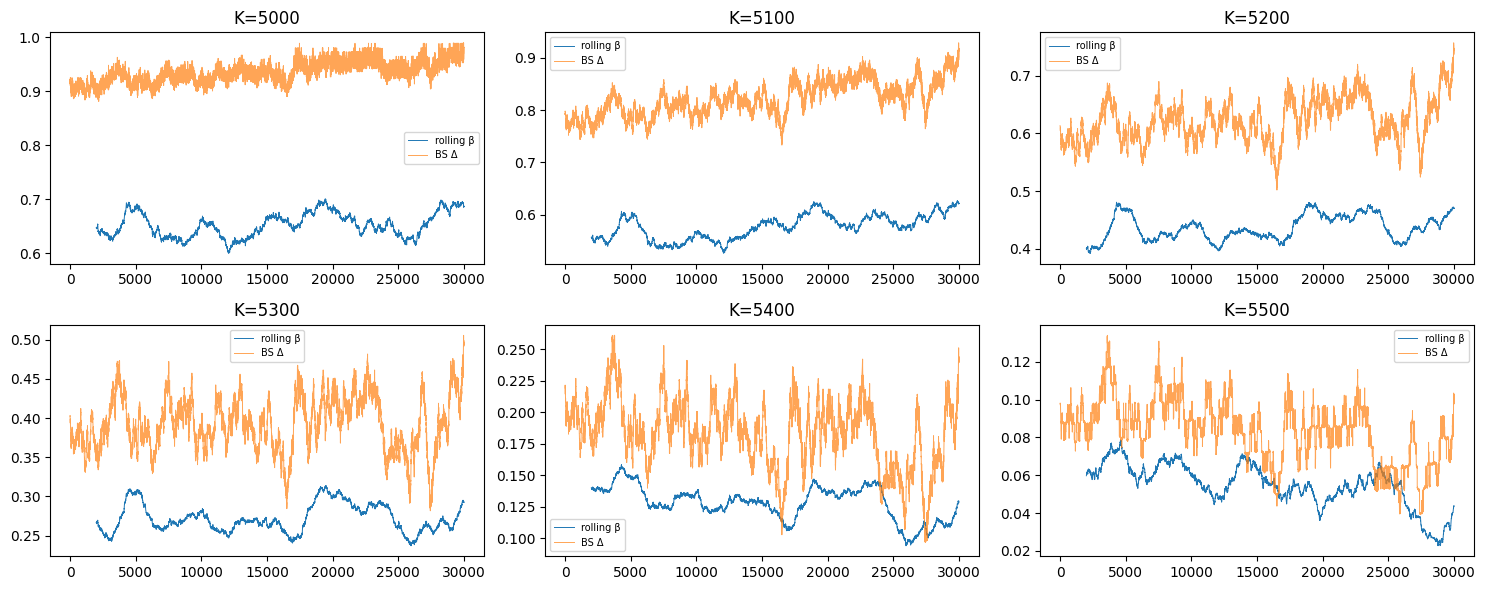

In [12]:
# rolling β vs BS delta — 6 个中段
fig, axes = plt.subplots(2,3,figsize=(15,6))
win = 2000
for ax, K in zip(axes.ravel(), [5000,5100,5200,5300,5400,5500]):
    dV = diff_no_cross(mid[f'VEV_{K}'], day_ser)
    df = pd.concat([dS, dV], axis=1).dropna(); df.columns=['dS','dV']
    rb = (df['dS'].rolling(win).cov(df['dV'])/df['dS'].rolling(win).var()).values
    sub = pd.concat([S,T_ser,iv[f'iv_{K}']],axis=1).dropna(); sub.columns=['S','T','iv']
    bsd = np.array([bs_delta(s,K,t,v) for s,t,v in zip(sub['S'],sub['T'],sub['iv'])])
    ax.plot(rb, lw=0.7, label='rolling β')
    ax.plot(np.linspace(0,len(rb)-1,len(bsd)), bsd, lw=0.7, label='BS Δ', alpha=0.7)
    ax.set_title(f'K={K}'); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Section 4 — IV mean-reversion

In [13]:
rows = []
tick_minutes = 1.0  # tick→分钟换算未知；这里仅用 tick 表示
for K in [5000,5100,5200,5300,5400,5500]:
    s = iv[f'iv_{K}'].dropna()
    if len(s) < 500:
        rows.append({'K':K}); continue
    # ADF
    adf_p = adfuller(s.values, autolag='AIC')[1]
    # AR(1)
    x = s.values[:-1]; y = s.values[1:]
    A = np.c_[np.ones_like(x), x]
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, rho = coef
    half = -np.log(2)/np.log(rho) if 0 < rho < 1 else np.inf
    # vega & IV daily std
    sub = pd.concat([S,T_ser,iv[f'iv_{K}']],axis=1).dropna(); sub.columns=['S','T','iv']
    vega_avg = np.mean([bs_vega(ss,K,tt,vv) for ss,tt,vv in zip(sub['S'],sub['T'],sub['iv'])])
    iv_with_day = pd.concat([iv[f'iv_{K}'], day_ser.rename('day')], axis=1).dropna()
    daily_stds = iv_with_day.groupby('day')[f'iv_{K}'].std()
    iv_daily_std = daily_stds.mean()
    rows.append({
        'K':K,'ADF_p':adf_p,'AR1_rho':rho,'half_life_ticks':half,
        'mean_revert?': (adf_p<0.05) and (50 < half < 5000),
        'vega_avg':vega_avg,'iv_daily_std':iv_daily_std,
        'vega_pnl_std_per_day': vega_avg*iv_daily_std,
    })
tab4 = pd.DataFrame(rows)
tab4.round(4)

,K,ADF_p,AR1_rho,half_life_ticks,mean_revert?,vega_avg,iv_daily_std,vega_pnl_std_per_day
0,5000,0.0000,0.1462,0.3605,False,87.6581,0.0069,0.6022
1,5100,0.1199,0.7544,2.4595,False,181.5445,0.0037,0.6781
2,5200,0.1457,0.8304,3.7291,False,264.3510,0.0029,0.7575
3,5300,0.3865,0.9387,10.9648,False,267.6165,0.0025,0.6701
4,5400,0.0206,0.9391,11.0406,False,184.9666,0.0034,0.6299
5,5500,0.0000,0.9250,8.8953,False,107.3456,0.0036,0.3873


## Section 5 — Verdict 汇总

In [14]:
verdict = []
fr = tab23.set_index('product')
d_tab = tab2.set_index('K')
v_tab = tab4.set_index('K') if len(tab4) else None
for K in STRIKES:
    prod = f'VEV_{K}'
    row = {'voucher':prod,'K':K}
    row['BS_delta_avg'] = d_tab.loc[K,'BS_delta_avg']
    row['beta'] = d_tab.loc[K,'beta']
    row['R2'] = d_tab.loc[K,'R2']
    row['fill_bid'] = fr.loc[prod,'fill_rate_bid']
    row['fill_ask'] = fr.loc[prod,'fill_rate_ask']
    row['spread'] = fr.loc[prod,'avg_spread']
    if K in (4000,4500):
        # delta 工具或不碰
        if row['fill_bid']>0.001 and row['fill_ask']>0.001 and row['R2']>0.7:
            role = 'delta 工具（被动 hedge）'
        elif row['R2']>0.7:
            role = 'delta 工具（单边）'
        else:
            role = '不碰'
        hedge = f"β={row['beta']:.3f}"
        row.update({'role':role,'hedge_ratio':hedge,'half_life':'N/A','vega':np.nan})
    else:
        if v_tab is not None and K in v_tab.index:
            mr = v_tab.loc[K]
            half = mr['half_life_ticks']; vega = mr['vega_avg']
            if mr['mean_revert?']:
                role = 'vega alpha'
            else:
                role = '不碰（IV 非 MR）'
            hedge = 'BS Δ (per-tick)' if abs(row['beta']-row['BS_delta_avg'])/abs(row['BS_delta_avg'])<0.05 else f"实测 β={row['beta']:.3f}"
        else:
            role,hedge,half,vega = '?','?',np.nan,np.nan
        row.update({'role':role,'hedge_ratio':hedge,'half_life':half,'vega':vega})
    verdict.append(row)
verdict_df = pd.DataFrame(verdict)
verdict_df.round(4)

,voucher,K,BS_delta_avg,beta,R2,fill_bid,fill_ask,spread,role,hedge_ratio,half_life,vega
0,VEV_4000,4000,0.9938,0.8100,0.3163,0.0079,0.0075,20.8135,不碰,β=0.810,N/A,NaN
1,VEV_4500,4500,0.9936,0.7160,0.4271,0.0000,0.0000,15.8527,不碰,β=0.716,N/A,NaN
2,VEV_5000,5000,0.9359,0.6530,0.5695,0.0000,0.0000,6.0433,不碰（IV 非 MR）,实测 β=0.653,0.36054,87.6581
3,VEV_5100,5100,0.8222,0.5773,0.5857,0.0000,0.0000,4.2958,不碰（IV 非 MR）,实测 β=0.577,2.459463,181.5445
4,VEV_5200,5200,0.6233,0.4367,0.5147,0.0006,0.0000,2.8881,不碰（IV 非 MR）,实测 β=0.437,3.729069,264.3510
5,VEV_5300,5300,0.3926,0.2727,0.3864,0.0040,0.0000,2.1068,不碰（IV 非 MR）,实测 β=0.273,10.96482,267.6165
6,VEV_5400,5400,0.1832,0.1289,0.2917,0.0075,0.0000,1.3814,不碰（IV 非 MR）,实测 β=0.129,11.040597,184.9666
7,VEV_5500,5500,0.0835,0.0549,0.1213,0.0089,0.0000,1.1498,不碰（IV 非 MR）,实测 β=0.055,8.89535,107.3456


## Section 6 — Portfolio vega 预算

In [15]:
alpha_K = [r['K'] for r in verdict if r['role']=='vega alpha']
print('vega alpha vouchers:', alpha_K)
if alpha_K:
    # 单 voucher 满仓 (300 lot) 的 vega PnL std/day
    iv_d = iv[[f'iv_{k}' for k in alpha_K]].copy()
    iv_d['day'] = day_ser.values
    div = iv_d.groupby('day').diff().drop(columns='day')
    cov = div.cov() * (TICKS_PER_DAY)  # tick→day 方差缩放（diff per tick → daily）
    vegas = tab4.set_index('K').loc[alpha_K,'vega_avg'].values
    pos = np.full(len(alpha_K), POS_LIMIT_VOUCHER)
    iv_daily_std = np.sqrt(np.diag(cov))
    single_pnl_std = np.abs(vegas)*iv_daily_std*POS_LIMIT_VOUCHER
    # 同方向满仓 portfolio vega PnL std
    sigma_v = np.diag(np.abs(vegas)*pos)
    port_var = sigma_v @ cov.values @ sigma_v
    port_std = np.sqrt(port_var.sum())
    summary = pd.DataFrame({
        'K':alpha_K,'vega':vegas,'iv_daily_std':iv_daily_std,
        'single_full_pos_pnl_std_per_day':single_pnl_std,
    })
    print(summary.round(3))
    print(f'\nPortfolio (all {len(alpha_K)} vouchers, ±300 each, full-corr from cov) vega PnL std/day = {port_std:,.0f}')
else:
    print('没有 vega alpha 标的，跳过 portfolio 预算。')

vega alpha vouchers: []
没有 vega alpha 标的，跳过 portfolio 预算。


## 最终 verdict

运行后查看 `verdict_df`，并按以下规则填策略输入：

- **K=4000/4500**：若 R²≥0.95 且双边 fill_rate 都显著 → 用作 delta-1 工具（被动 hedge），β=实测；R² 0.7–0.95 → 脏 delta 工具，hedge 用实测 β 并预留残差；否则不碰。
- **K=5000–5500**：ADF p<0.05 且半衰期 in [50,5000] tick → vega alpha；否则不碰。hedge ratio 看实测 β 与 BS delta 偏差。
- **6000/6500 不进分析**（已排除）。

Portfolio：用 Section 6 的 `port_std` 与团队风险阈值比对，反算单 voucher 仓位上限。